In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
from matplotlib import pylab as pl
import numpy as np
import pandas as pd
# from matplotlib import cm

import cmcrameri.cm as cmc
from matplotlib import rcParams

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.io import loadmat
from matplotlib.colors import LogNorm

from statData import StatData

nu = 1.8e-5

In [2]:
def make_statlist(caseids, ids, case_info):
    time_window = [0,10]
    dirname = ''

    statlist = {}
    for id, case in zip(ids, caseids):
            casename = case.split('/')[0]
            cinf = case_info.loc[casename]
            stat_params = cinf.to_dict()
            fname = dirname+casename+'.txt'
            statlist[id] = StatData(fname, ustar=stat_params['ustar_mean'])
            # statlist[id] = StatData.PVstat(id, case, params=stat_params, dirname=dirname, 
            #                             time_index=1, time_window=time_window,
            #                             save_mean=False, read_save=True)
    
    return statlist

In [3]:
def plot_velocity(stats, ids, colors, linestyles=['-'], axs=[], 
                  labels=True, xlabel=True):
    if len(axs) == 0:
        fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, 
                                tight_layout=True, figsize=(8,4))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]
        u = stats[id].data['U']
        y = stats[id].data['ym']

        for axi in range(2):
            axs[axi].plot(u, y, lw=2, color=colors[i], ls=linestyles[i], 
                        label=id, zorder=1)
        
        # * viscous scaling
        ustar = stats[id].ustar
        H = 1000

        axs[2].plot(y[1:]/H, u[1:]/ustar, marker='.', ls=linestyles[i],
                    color=colors[i], label=id, zorder=1)
        
        # * some info
        print(ids[i])
        # print('U_bulk: {:.1f}'.format(stats[id].bulk_vel()))
        # print('U(1000): {:.1f}\n'.format(stats[id].Uz(1000)))
        print('U(150): {:.1f}'.format(stats[id].Uz(150)))
        print('U(20): {:.1f}\n'.format(stats[id].Uz(20)))


    axs[0].axhline(150, color='gainsboro', zorder=0)#, label='Example Turbine Hub')
    axs[2].axvline(150/H, color='gainsboro', zorder=0)

    # axs[0].axhline(20, color='gainsboro', zorder=0)
    axs[1].axhline(20, color='gainsboro', zorder=0)
    axs[2].axvline(20/H, color='gainsboro', zorder=0)

    # axs[0].axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    # axs[1].axvspan(30/H, 270/H, color='gainsboro', zorder=0)

    axs[0].set_ylim((0,1000))
    # axs[0].set_xlim((10,18))
    axs[0].set_xlim((10,27))

    axs[1].set_ylim((1,100))
    axs[1].set_xlim((2,21))

    for axi in range(2):
        if xlabel:
            axs[axi].set_xlabel('U (m/s)')
        axs[axi].set_ylabel('z (m)')

    if labels:
        axs[0].legend(loc='upper left', labelspacing=0.7)

    if xlabel:
        axs[2].set_xlabel(r'$z/H$')

    axs[2].set_ylabel(r'$\langle \overline{u}\rangle/u_\ast$')
    axs[2].set_xscale('log')
    axs[2].set_xlim((1e-3, 1))

    # return fig, axs

In [4]:
def plot_reynolds(stats, ids, colors, linestyles=['-'], fig=None, axs=None, labels=True):
    if not fig:
        fig, axs = plt.subplots(2, 3, facecolor='w', dpi=180, constrained_layout=True,
                                figsize=(10,6), sharey=True)

    plot_ids = ['up_up','vp_vp','wp_wp','up_vp','up_wp','vp_wp']
    plot_labels = [r"$\langle u'u'\rangle$", r"$\langle v'v'\rangle$",
                r"$\langle w'w'\rangle$", r"$\langle u'v'\rangle$",
                r"$\langle u'w'\rangle$", r"$\langle v'w'\rangle$"]


    for j in range(len(plot_ids)):
        axi = int(j/3)
        axj = j%3

        ax = axs[axi,axj]

        for i in range(len(ids)):
            id = ids[i]

            if labels:
                ax.plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                        lw=1.2, color=colors[i], ls=linestyles[i], label=id)
            else:
                ax.plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                    lw=1.2, color=colors[i], ls=linestyles[i])
            
        ax.axhline(150, color='gainsboro', label='Example Turbine Hub', zorder=0)
        # ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)

        if axj == 0:   
            ax.set_ylabel(r'$y$')
        ax.set_title(plot_labels[j])
        
        ax.set_ylim((0,1000))

    axs[0,0].legend()


In [5]:
def plot_upvp(stats, ids, colors, ax=False, labels=True, xlabel=True,
              linestyles=['-']):
    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180, figsize=(5.2,4.6))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]
        ax.plot(stats[id].data['up_vp'], stats[id].data['y'],
                lw=2, color=colors[i], linestyle=linestyles[i], label=id)

    # ax.axhline(150, color='gainsboro', zorder=0)
    ax.axhline(150, color='gainsboro', label='Example Turbine Hub', zorder=0)
    # ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    
    if xlabel:
        ax.set_xlabel(r"$\langle u'w' \rangle$ (m$^2$/s$^2$)")
    ax.set_ylabel(r'$z$ (m)')
    
    ax.set_ylim((0,1000))

    if labels:
        ax.legend()

In [6]:
def plot_tke(stats, ids, colors, ax=False, labels=True, xlabel=True,
              linestyles=['-']):
    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180, figsize=(5.2,4.6))

    if len(linestyles) < len(ids):
        linestyles = [linestyles[0] for i in range(len(ids))]

    for i in range(len(ids)):
        id = ids[i]

        ax.plot(stats[id].data['tke'], stats[id].data['y'],
                lw=2, color=colors[i], linestyle=linestyles[i], label=id)

        print('TKE(150) for '+id.replace("\n","").ljust(30)+': {:.2f}'.format(stats[id].Uz(150, val='tke')))


    # ax.axhline(150, color='gainsboro', zorder=0)
    ax.axhline(150, color='gainsboro', label='Example Turbine Hub Height', zorder=0)
    # ax.axhspan(30, 270, color='gainsboro', label='Example Turbine Rotor', zorder=0)
    
    if xlabel:
        ax.set_xlabel(r"$TKE$ (m$^2$/s$^2$)")
    ax.set_ylabel(r'$z$ (m)')
    
    ax.set_ylim((0,1000))

    if labels:
        ax.legend()

In [7]:
def coare_plot_starter(figsize, Romero_colorby='none', Romero_cmap='none'):

    # * COARE 3.5 formula
    ncoare = 500
    u10_coare = np.linspace(1,21,ncoare)
    ustar_coare = np.empty(ncoare)

    for i in range(ncoare):
        if u10_coare[i] < 4:
            ustar_coare[i] = 0.03 * u10_coare[i]
        elif u10_coare[i] < 9.6:
            ustar_coare[i] = 0.035 * u10_coare[i] - 0.005*4
        else:
            # ustar_coare[i] = 0.058 * u10_coare[i] - 0.24 # Andreas et al. (2012)
            ustar_coare[i] = 0.062 * u10_coare[i] - 0.28

    fig, ax = plt.subplots(1,1,facecolor='w', dpi=180.0,tight_layout=True, figsize=figsize)

    # * Edson
    # ed = edson.EdsonData()
    # ed.fill_outer_region(ax)
    # ed.fill_med_region(ax)
    # plt.plot(u10_coare,ustar_coare,'k',lw=2.5,label='COARE 3.5 (Edson et al. 2013)', zorder=2)

    ed = loadmat('experimental_data/TauDataEdson.mat')
    plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=6, marker='x', 
                color='#3a1124', alpha=0.4, lw=0.3,
                # color='lightgray', lw=0.5, #'gainsboro', 
                label='Edson et al. 2013', zorder=1)
    

    # * Romero data (GOTEX)
    rom = pd.read_csv('experimental_data/romero_summary.csv', header=0, sep=' ',index_col=False)
    rom['hs'] = 4*np.sqrt(rom['eta_sq'])
    rom['kphs'] = rom['hs']*rom['kp']

    if Romero_colorby == 'none':
        ax.scatter(rom['U10'],rom['ustar'],c='black',
                   s=5,label='GOTEX',zorder=2)
    elif Romero_colorby == 'hs':
        rsc = ax.scatter(rom['U10'],rom['ustar'],c=rom['hs'],
                            cmap=Romero_cmap, vmin=0, vmax=4,
                            s=5,label='GOTEX',zorder=2)
        plt.colorbar(rsc, label=r'Romero $H_s$')
    elif Romero_colorby == 'kphs':
        rsc = ax.scatter(rom['U10'],rom['ustar'],c=rom['kphs'],
                            cmap=Romero_cmap, vmin=0, vmax=0.3,
                            s=5,label='GOTEX',zorder=2)
        plt.colorbar(rsc, label=r'$k_pH_s$')


    # * COARE 3.5 line
    plt.plot(u10_coare,ustar_coare,
            color='silver',#'k',
            lw=2,label='COARE 3.5', zorder=2)

    ax.set_xlabel(r'$U_{10}$ (m/s)')
    ax.set_ylabel(r'$u_*$ (m/s)')

    ax.legend()

    ax.set_xlim((0,21.0))
    ax.set_ylim((0,1.2))
    
    # ax.set_xlim((0,24.0))
    # ax.set_ylim((0,1.4))

    return fig, ax

    

In [8]:
def plot_charnock(ax, color='k', ls='-', lw=1.5, label='Charnock 1955'):
    ch_ustars = np.linspace(1e-3,0.9, 500)
    charnock_U10s = ch_ustars / 0.4 * np.log(10*9.81 / 0.011 / ch_ustars**2)

    ax.plot(charnock_U10s, ch_ustars, 
            color=color, ls=ls, lw=lw, label=label)

In [9]:
def plot_coare(ax, color='k', ls='-', lw=1.5, label='COARE 3.5'):
    # * COARE 3.5 formula
    ncoare = 500
    u10_coare = np.linspace(1,20,ncoare)
    ustar_coare = np.empty(ncoare)

    for i in range(ncoare):
        if u10_coare[i] < 4:
            ustar_coare[i] = 0.03 * u10_coare[i]
        elif u10_coare[i] < 9.6:
            ustar_coare[i] = 0.035 * u10_coare[i] - 0.005*4
        else:
            # ustar_coare[i] = 0.058 * u10_coare[i] - 0.24 # Andreas et al. (2012)
            ustar_coare[i] = 0.062 * u10_coare[i] - 0.28

    ax.plot(u10_coare,ustar_coare,
            color=color, ls=ls, lw=lw, label=label,
              zorder=2)

In [10]:
def plot_ncar(ax, color='k', ls='--', lw=1.5, label = 'Large et al. 2004'):
    nu10 = 500
    u10 = np.linspace(1,21,nu10)

    # * NCAR formulation
    ncard = 0.0027 / u10 + 0.000142 + 0.0000764 * u10
    ustar_ncar = np.sqrt(ncard) * u10

    ax.plot(u10, ustar_ncar,
            color=color, ls=ls, lw=lw, label=label,
            zorder=2)


In [11]:
def z0(U10, ustar):
    kappa = 0.4
    z0 = 10 / np.exp(U10*kappa/ustar)
    return z0

In [12]:
def coare_color_by_z0(ax_in, xlim, ylim):
    res = 1000
    u10s = np.linspace(xlim[0],xlim[1],res)
    ustars = np.linspace(ylim[0]+0.01,ylim[1],res)

    X, Y = np.meshgrid(u10s, ustars)
    Z = z0(X,Y)
    # levels = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 10)
    levels = np.logspace(-8,1,10)
    # levels = np.logspace(-10,1,12)

    if not ax_in:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180.0,tight_layout=True,figsize=(6,5))
        plt.xlabel(r'$U_{10}$ (m/s)')
        plt.ylabel(r'$u_*$ (m/s)')
    else:
        ax = ax_in

    cmap = cmc.lapaz_r
    # cmap = cmc.glasgow_r

    contours = ax.contour(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)
    cf = ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)
    # ax.clabel(contours, inline=True, fontsize=10, fmt="%.1e", colors='black')
    # fig.colorbar(cf, label=r"$z_0$", ticks=levels)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if not ax_in:
        return fig, ax

    # plt.xlabel(r'$U_{10}$ (m/s)')
    # plt.ylabel(r'$u_*$ (m/s)')

# $z_0$ contours

/tmp/ipykernel_2564194/3439129844.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=6, marker='x',
/tmp/ipykernel_2564194/4102278361.py:3: RuntimeWarning: overflow encountered in exp
  z0 = 10 / np.exp(U10*kappa/ustar)
/tmp/ipykernel_2564194/1874560041.py:22: UserWarning: Log scale: values of z <= 0 have been masked
  contours = ax.contour(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)
/tmp/ipykernel_2564194/1874560041.py:23: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)


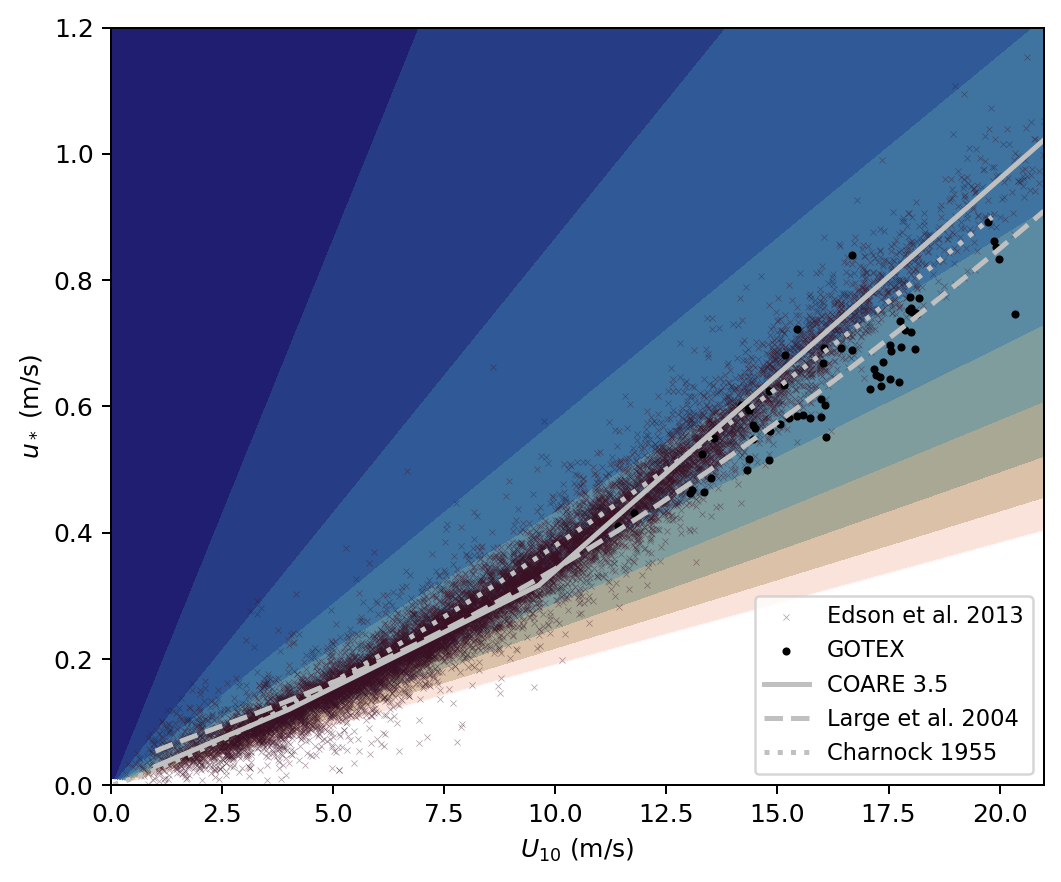

In [30]:
xlim = (0, 21)
ylim = (0, 1.2)

# ~ to check against aspect ratio in Edson et al
# fig, ax = coare_plot_starter(figsize=(12,4.85))

# ~  z0 contours under edson, coare, romero
fig, ax = coare_plot_starter(figsize=(6,5))
coare_color_by_z0(ax, xlim, ylim)

# ~ just z0 contours
# fig, ax = coare_color_by_z0(False, xlim, ylim)
# plot_coare(ax, label='COARE 3.5 (Edson et al. 2013)')

plot_ncar(ax, lw=2, color='silver')
plot_charnock(ax, ls=':', lw=2, color='silver')

ax.legend(loc='lower right', fontsize=9)
# plt.savefig('figures/z0_contours.pdf')

# Compare Equilibrium vs. JONSWAP in LES (using NGA)

### $H_s$ = 0.4 m

In [42]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS04_kp07', 'HS04_js', 'HS04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']
colors = ['black', 'mediumseagreen', 'dodgerblue']

ids = ['Sp A '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

U(150) for Sp A Equilibrium: 16.49
U(150) for Sp A JONSWAP naive: 16.53
U(150) for Sp A JONSWAP matched: 16.68


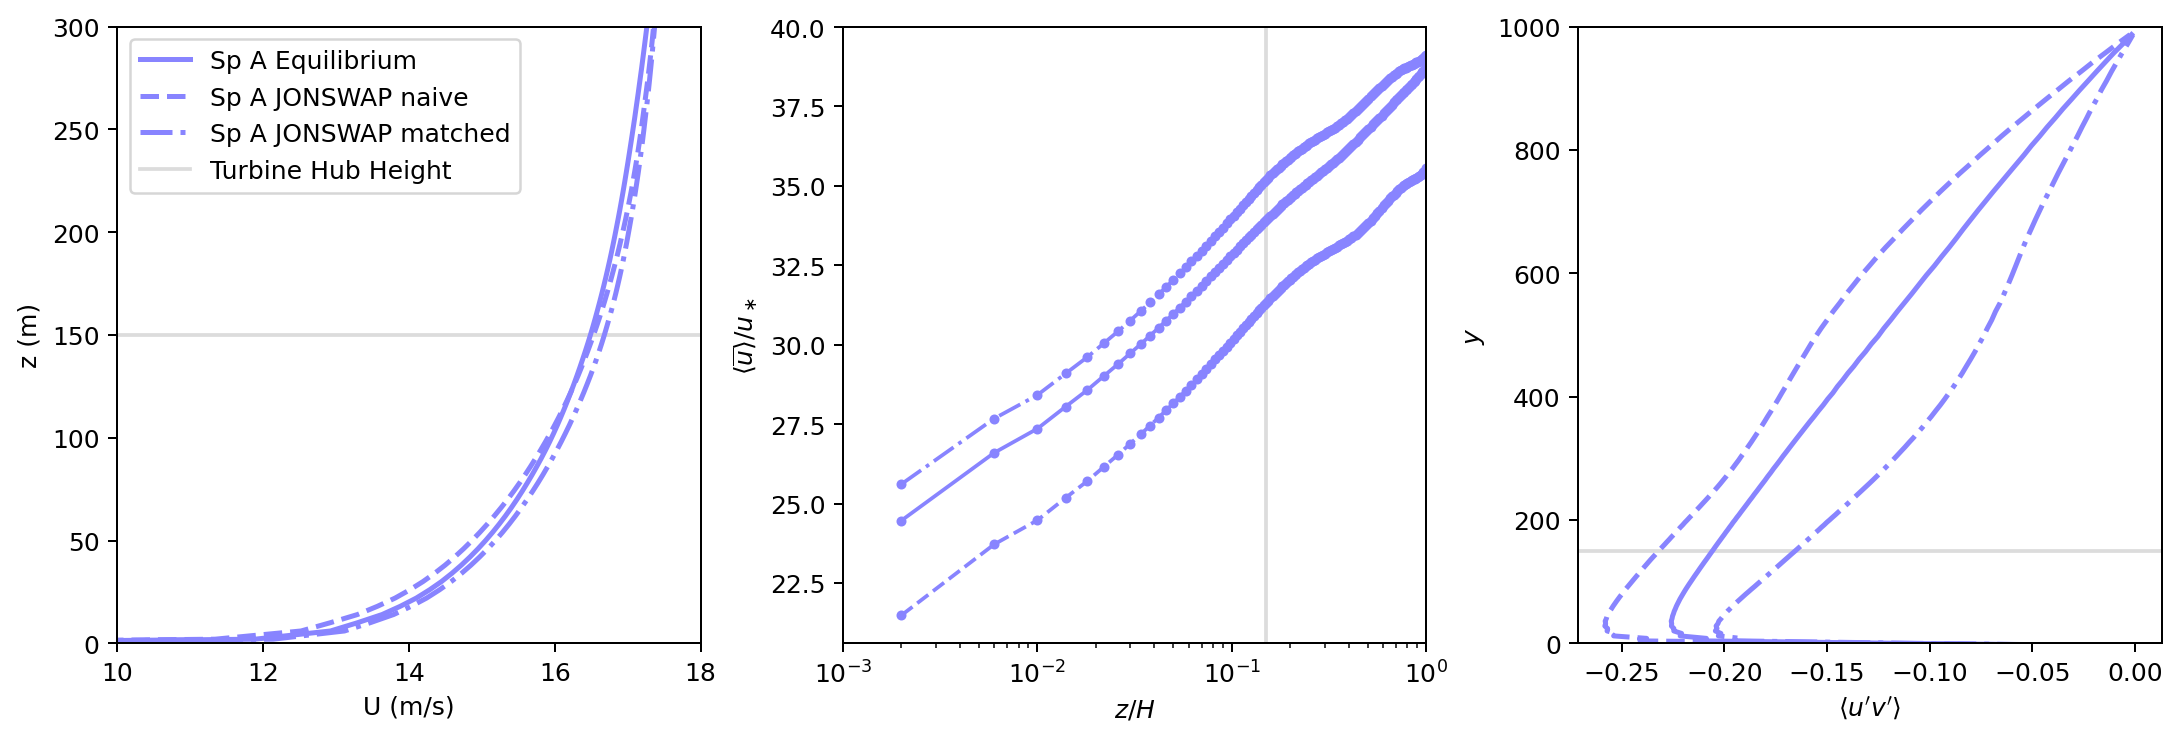

In [ ]:
fig, axs = plt.subplots(1,3,facecolor='w', dpi=180.0, figsize=(12,4))

labels = ['Equilibrium', 'JONSWAP from algorithm', 'JONSWAP matched energy']
colors = ['#8884FF' for i in range(len(ids))]

# print(axs[0:2])

plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=['-','--','-.'],
              )

plot_upvp(statlist, ids, colors, ax=axs[2], labels=False,
          linestyles=['-','--','-.'])

fig.set_constrained_layout(True)
fig.savefig('figures/Hs04_profiles.pdf')

/tmp/ipykernel_1244540/1769906107.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']), s=10, marker='x', lw=1,


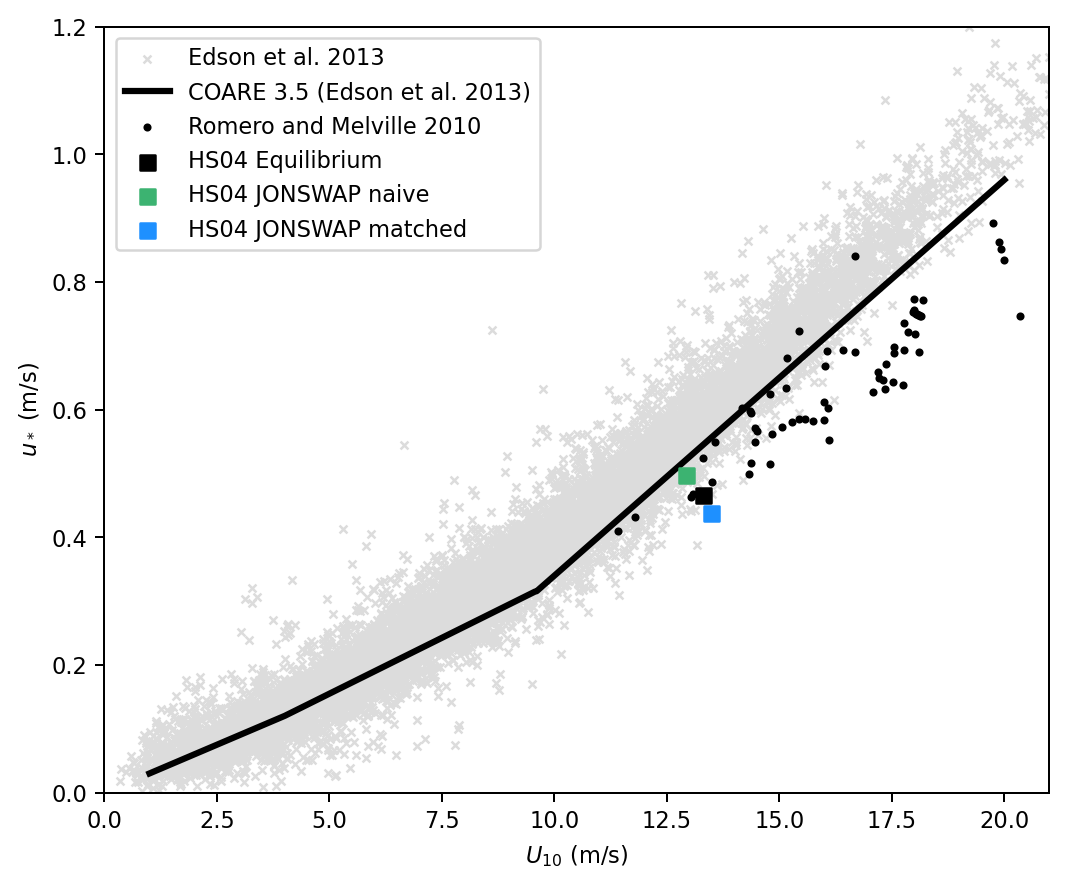

In [ ]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,5))

hs04_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs04_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs04_u10s[i], hs04_ustars[i], c=colors[i], marker='s',
               label=ids[i], zorder=3)

ax.legend()

### $k_p$ = 0.0393 m $^{-1}$

In [ ]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS12_kp04', 'kp04_js', 'kp04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']

ids = ['Sp B '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

U(150) for Sp B Equilibrium: 16.03
U(150) for Sp B JONSWAP naive: 16.34
U(150) for Sp B JONSWAP matched: 16.23


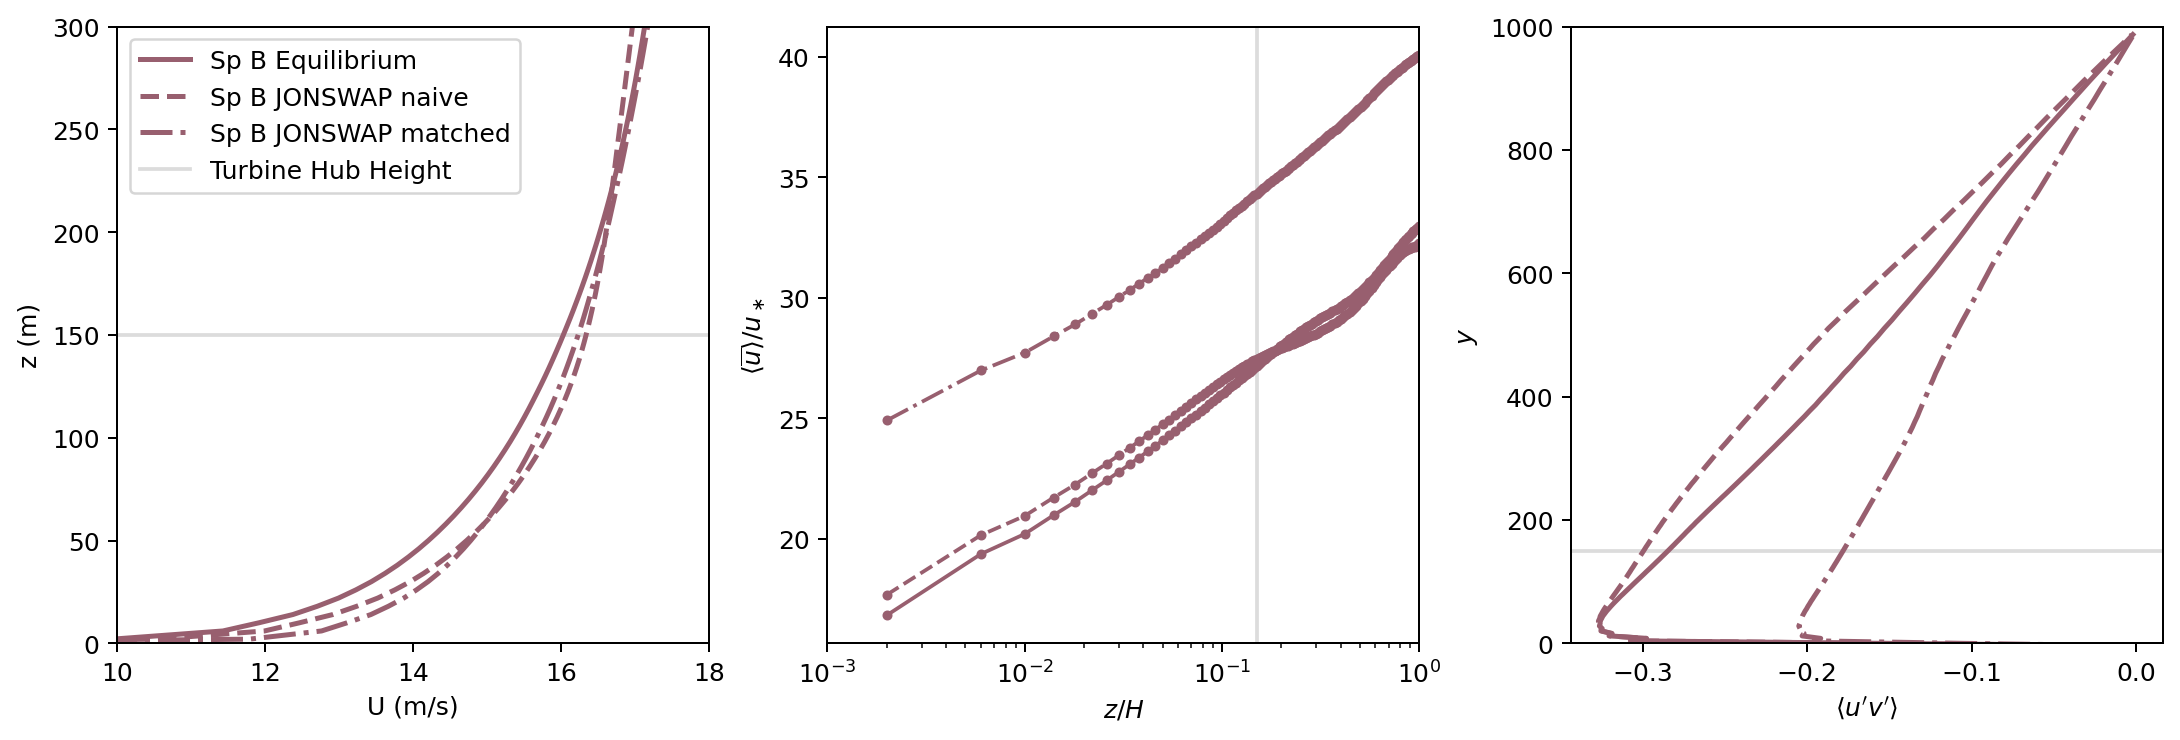

In [40]:
fig, axs = plt.subplots(1,3,facecolor='w', dpi=180.0, tight_layout=True, figsize=(12,4))

labels = ['Equilibrium', 'JONSWAP from algorithm', 'JONSWAP matched energy']
colors = ['#985F6F' for i in range(len(ids))]

plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=['-','--','-.'],
              )

plot_upvp(statlist, ids, colors, ax=axs[2], labels=False,
          linestyles=['-','--','-.'])

fig.set_constrained_layout(True)
fig.savefig('figures/kp04_profiles.pdf')

/tmp/ipykernel_1244540/1769906107.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']), s=10, marker='x', lw=1,


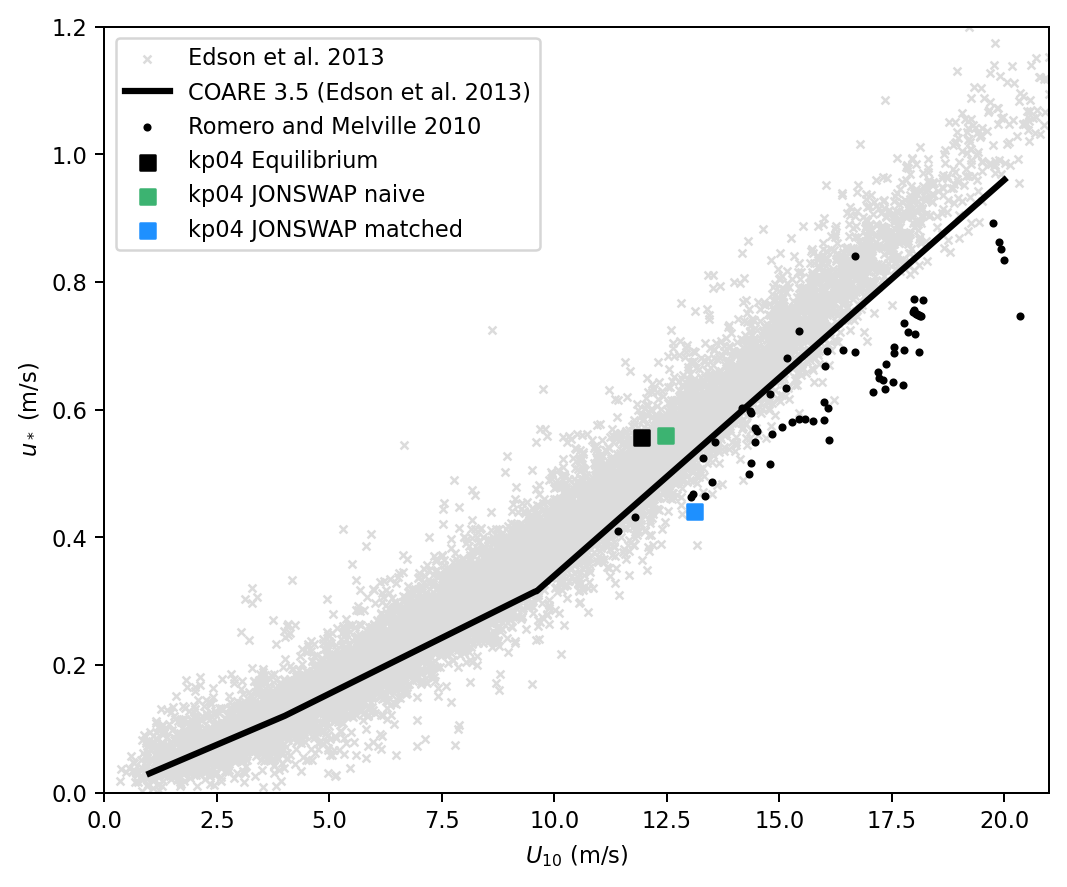

In [ ]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,5))

hs04_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs04_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs04_u10s[i], hs04_ustars[i], c=colors[i], marker='s',
               label=ids[i], zorder=3)

ax.legend()

## together

In [13]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

U18cases = ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match']
U_ids = ['Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
       'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       'Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
       'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched']

U_cases = ['HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'HS12_kp16_swell', 'kp16_js', 'kp16_js_match']


U24cases = ['U24_'+cname for cname in U_cases]
U24ids = ['U24 '+idname for idname in U_ids]

U12cases = ['U12_'+cname for cname in U_cases]
U12ids = ['U12 '+idname for idname in U_ids]

U18ids = ['U18 '+idname for idname in U_ids]

cases = U12cases + U18cases + U24cases
ids = U12ids + U18ids + U24ids

# cases = ['U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
#         'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match',
#        #  'U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
#        #  'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
#         ]
# ids = ['Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
#        'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched',
#        # 'Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
#        # 'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       # ]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)


### COARE plot ($U_{10}$ vs. $u_\ast$)

/tmp/ipykernel_2256926/2619580190.py:26: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=6, marker='x',


Text(0.7, 0.35, '$U_0$ = 24 m/s')

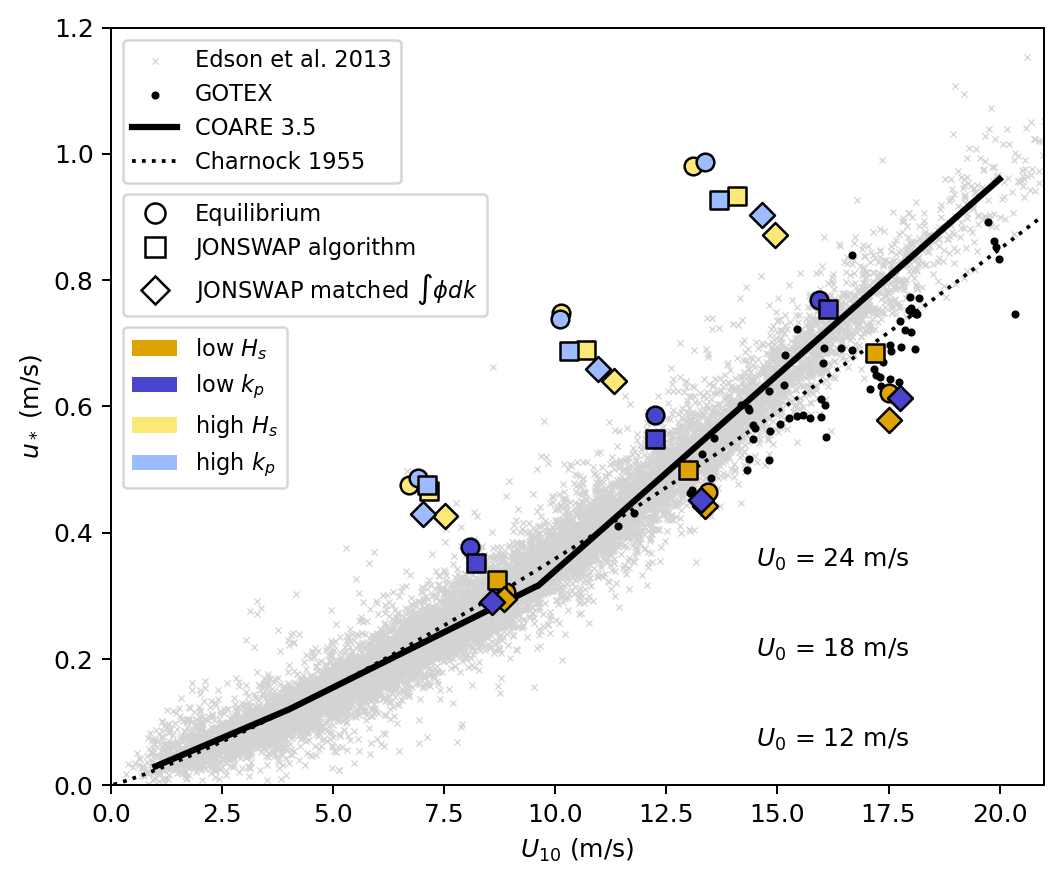

In [24]:
rcParams.update({'font.size': 10})
z_us = [0,100]

fig, ax = coare_plot_starter(figsize=(6,5))

ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
# ustars = [stat.ustar for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]
 
# colors = ['#8884FF', '#985F6F', 'dodgerblue', 'crimson']
# colors = ['#294D4A', '#776472', '#A799B7', '#AEC3B0']
colors = ['#DEA404', '#4844CB', '#FAE877', '#9CBCFF']
# markers = ['s', '^', 'v']
markers = ['o', 's', 'D']

colors = colors + colors + colors

for i in range(len(statlist)):
    ax.scatter(u10s[i], ustars[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    

plot_charnock(ax, color='k', ls=':', label='Charnock 1955')

# * build legend
# shape_labels = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP \nmatched energy']
shape_labels = ['Equilibrium', 'JONSWAP algorithm', r'JONSWAP matched $\int\phi dk$']
shape_handles = [
    Line2D([0], [0], marker=m, color='k', markerfacecolor='white',
           linestyle='None', markersize=8)
    for m in markers ]
# color_labels = ['Spectrum A', 'Spectrum B']
# color_labels = ['HS04', 'kp04', 'HS20', 'kp16']
# color_labels = [r'$H_S = 0.4$m, $k_p = 0.0785$m$^{-1}$',
#                 r'$H_S = 1.2$m, $k_p = 0.0393$m$^{-1}$', 
#                 r'$H_S = 2.0$m, $k_p = 0.0785$m$^{-1}$', 
#                 r'$H_S = 1.2$m, $k_p = 0.157$m$^{-1}$']
color_labels = [r'low $H_s$',# ($H_sk_p$=0.031)',
                r'low $k_p$',# ($H_sk_p$=0.047)',
                r'high $H_s$',# ($H_sk_p$=0.157)',
                r'high $k_p$',# ($H_sk_p$=0.188)']
]
color_handles = [
    Patch(facecolor=c, edgecolor='none')
    for c in colors ]

handles, labels = ax.get_legend_handles_labels()
# handles += shape_handles
# labels += shape_labels
# handles += color_handles
# labels += color_labels
# ax.legend(handles, labels, fontsize=9)


leg1 = ax.legend(handles, labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.999))
leg2 = ax.legend(shape_handles, shape_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.795))
leg3 = ax.legend(color_handles, color_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.62))

ax.add_artist(leg1)
ax.add_artist(leg2)

ax.annotate(r'$U_0$ = 12 m/s', (0.7, 0.15), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 18 m/s', (0.7, 0.25), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 24 m/s', (0.7, 0.35), xycoords='figure fraction')


# ax.set_ylim((0.2,1.2))
# ax.set_xlim((5,21))

# ax.set_ylim((0.6, 0.9))
# ax.set_xlim((9,11))

# fig.savefig('figures/les_comparison.pdf')

get values of $c_p/u_\ast$ and $c_p/U_{10}$ for Equilibrium cases at $U_0$ = 18 m/s

In [ ]:

cps = [11.18, 15.80, 11.18, 7.91]

cases = ['U18_HS04_kp07_swell',
        'U18_HS12_kp04_swell', 
        'U18_HS20_kp07_swell', 
        'U18_HS12_kp16_swell']
U_ids = ['low Hs', 'low kp', 'high Hs', 'high kp']

caseids = [case+'/'+case for case in cases]
statlist = make_statlist(caseids, ids, case_info)

ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
# ustars = [stat.ustar for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(cps)):
    print(U_ids[i])
    print('cp/u*: {:.2f}'.format(cps[i]/ustars[i]))
    print('cp/U10: {:.2f}'.format(cps[i]/u10s[i]))

#     print('\n u*: {:.2f}'.format(ustars[i+12]))
    print('\nu*: {:.2f}'.format(ustars[i]))
    print('U10: {:.2f}'.format(u10s[i]))
    print('__\n')


low Hs
cp/u*: 24.09
cp/U10: 0.83

u*: 0.46
U10: 13.43
__

low kp
cp/u*: 26.93
cp/U10: 1.29

u*: 0.59
U10: 12.24
__

high Hs
cp/u*: 14.96
cp/U10: 1.10

u*: 0.75
U10: 10.13
__

high kp
cp/u*: 10.72
cp/U10: 0.78

u*: 0.74
U10: 10.10
__



### to plot vertical profiles

In [13]:
def wavecase_statlist(cases, label):
    case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

    ids = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP \nmatched energy']
    ids = [label+' '+id for id in ids]

    caseids = [case+'/'+case for case in cases]
    statlist = make_statlist(caseids, ids, case_info)

    return statlist, ids

In [14]:
def plot_wave_profiles(statlist, ids, axs, color, xlabel=False, labels=False):
    ls = ['-','--',':']
    colors = [color for i in range(len(ids))]

    plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=ls, xlabel=xlabel,
              )
    
    print('')

    plot_upvp(statlist, ids, colors, ax=axs[2], labels=False, xlabel=xlabel,
          linestyles=ls)
    
    plot_tke(statlist, ids, colors, ax=axs[3], labels=False, xlabel=xlabel,
          linestyles=ls)




### many cases

In [11]:

# hs04_statlist, hs04_ids = wavecase_statlist(
#     ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match'],
#     'HS04'
#     )

# kp04_statlist, kp04_ids = wavecase_statlist(
#     ['U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match'],
#     'kp04')


# hs20_statlist, hs20_ids = wavecase_statlist(
#     ['U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match'],
#     'HS20')

# kp16_statlist, kp16_ids = wavecase_statlist(
#     ['U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match'],
#     'kp16')

hs04_statlist, hs04_ids = wavecase_statlist(
    U24cases[0:3], 'HS04',
    )

kp04_statlist, kp04_ids = wavecase_statlist(
    U24cases[3:6], 'kp04',
    )
print(kp04_ids)
print(kp04_statlist.keys())

hs20_statlist, hs20_ids = wavecase_statlist(
    U24cases[6:9], 'HS20',
    )

kp16_statlist, kp16_ids = wavecase_statlist(
    U24cases[9:12], 'kp16',
    )


NameError: name 'U24cases' is not defined

In [23]:
z1 = 150-240/2
z2 = 150+240/2

allstats = {**hs04_statlist, **kp04_statlist}

print('Power difference for average velocity across rotor')
print('--------------------------------------------------\n')

for id in hs04_ids + kp04_ids:
    stat = allstats[id]
    Umean = stat.mean_Uz(z1, z2)
    print('<U> across rotor for '+id.replace("\n","").ljust(30)+': {:.3f}'.format(Umean))

# print('\n--------------------------------------------------\n')
# print('Spec A power difference 3.05%')
# print('Spec B power difference 4.87%')

Power difference for average velocity across rotor
--------------------------------------------------

<U> across rotor for HS04 Equilibrium              : 21.590
<U> across rotor for HS04 JONSWAP from algorithm   : 21.666
<U> across rotor for HS04 JONSWAP matched energy   : 21.422
<U> across rotor for kp04 Equilibrium              : 21.084
<U> across rotor for kp04 JONSWAP from algorithm   : 21.221
<U> across rotor for kp04 JONSWAP matched energy   : 21.775


Power difference for average velocity at hub height
---------------------------------------------------

U(150) for HS04 Equilibrium              : 21.82
U(150) for HS04 JONSWAP from algorithm   : 21.94
U(150) for HS04 JONSWAP matched energy   : 21.62

U(150) for kp04 Equilibrium              : 21.40
U(150) for kp04 JONSWAP from algorithm   : 21.51
U(150) for kp04 JONSWAP matched energy   : 22.02

U(150) for HS20 Equilibrium              : 20.66
U(150) for HS20 JONSWAP from algorithm   : 21.13
U(150) for HS20 JONSWAP matched energy   : 21.33

U(150) for kp16 Equilibrium              : 20.89
U(150) for kp16 JONSWAP from algorithm   : 21.24
U(150) for kp16 JONSWAP matched energy   : 21.24



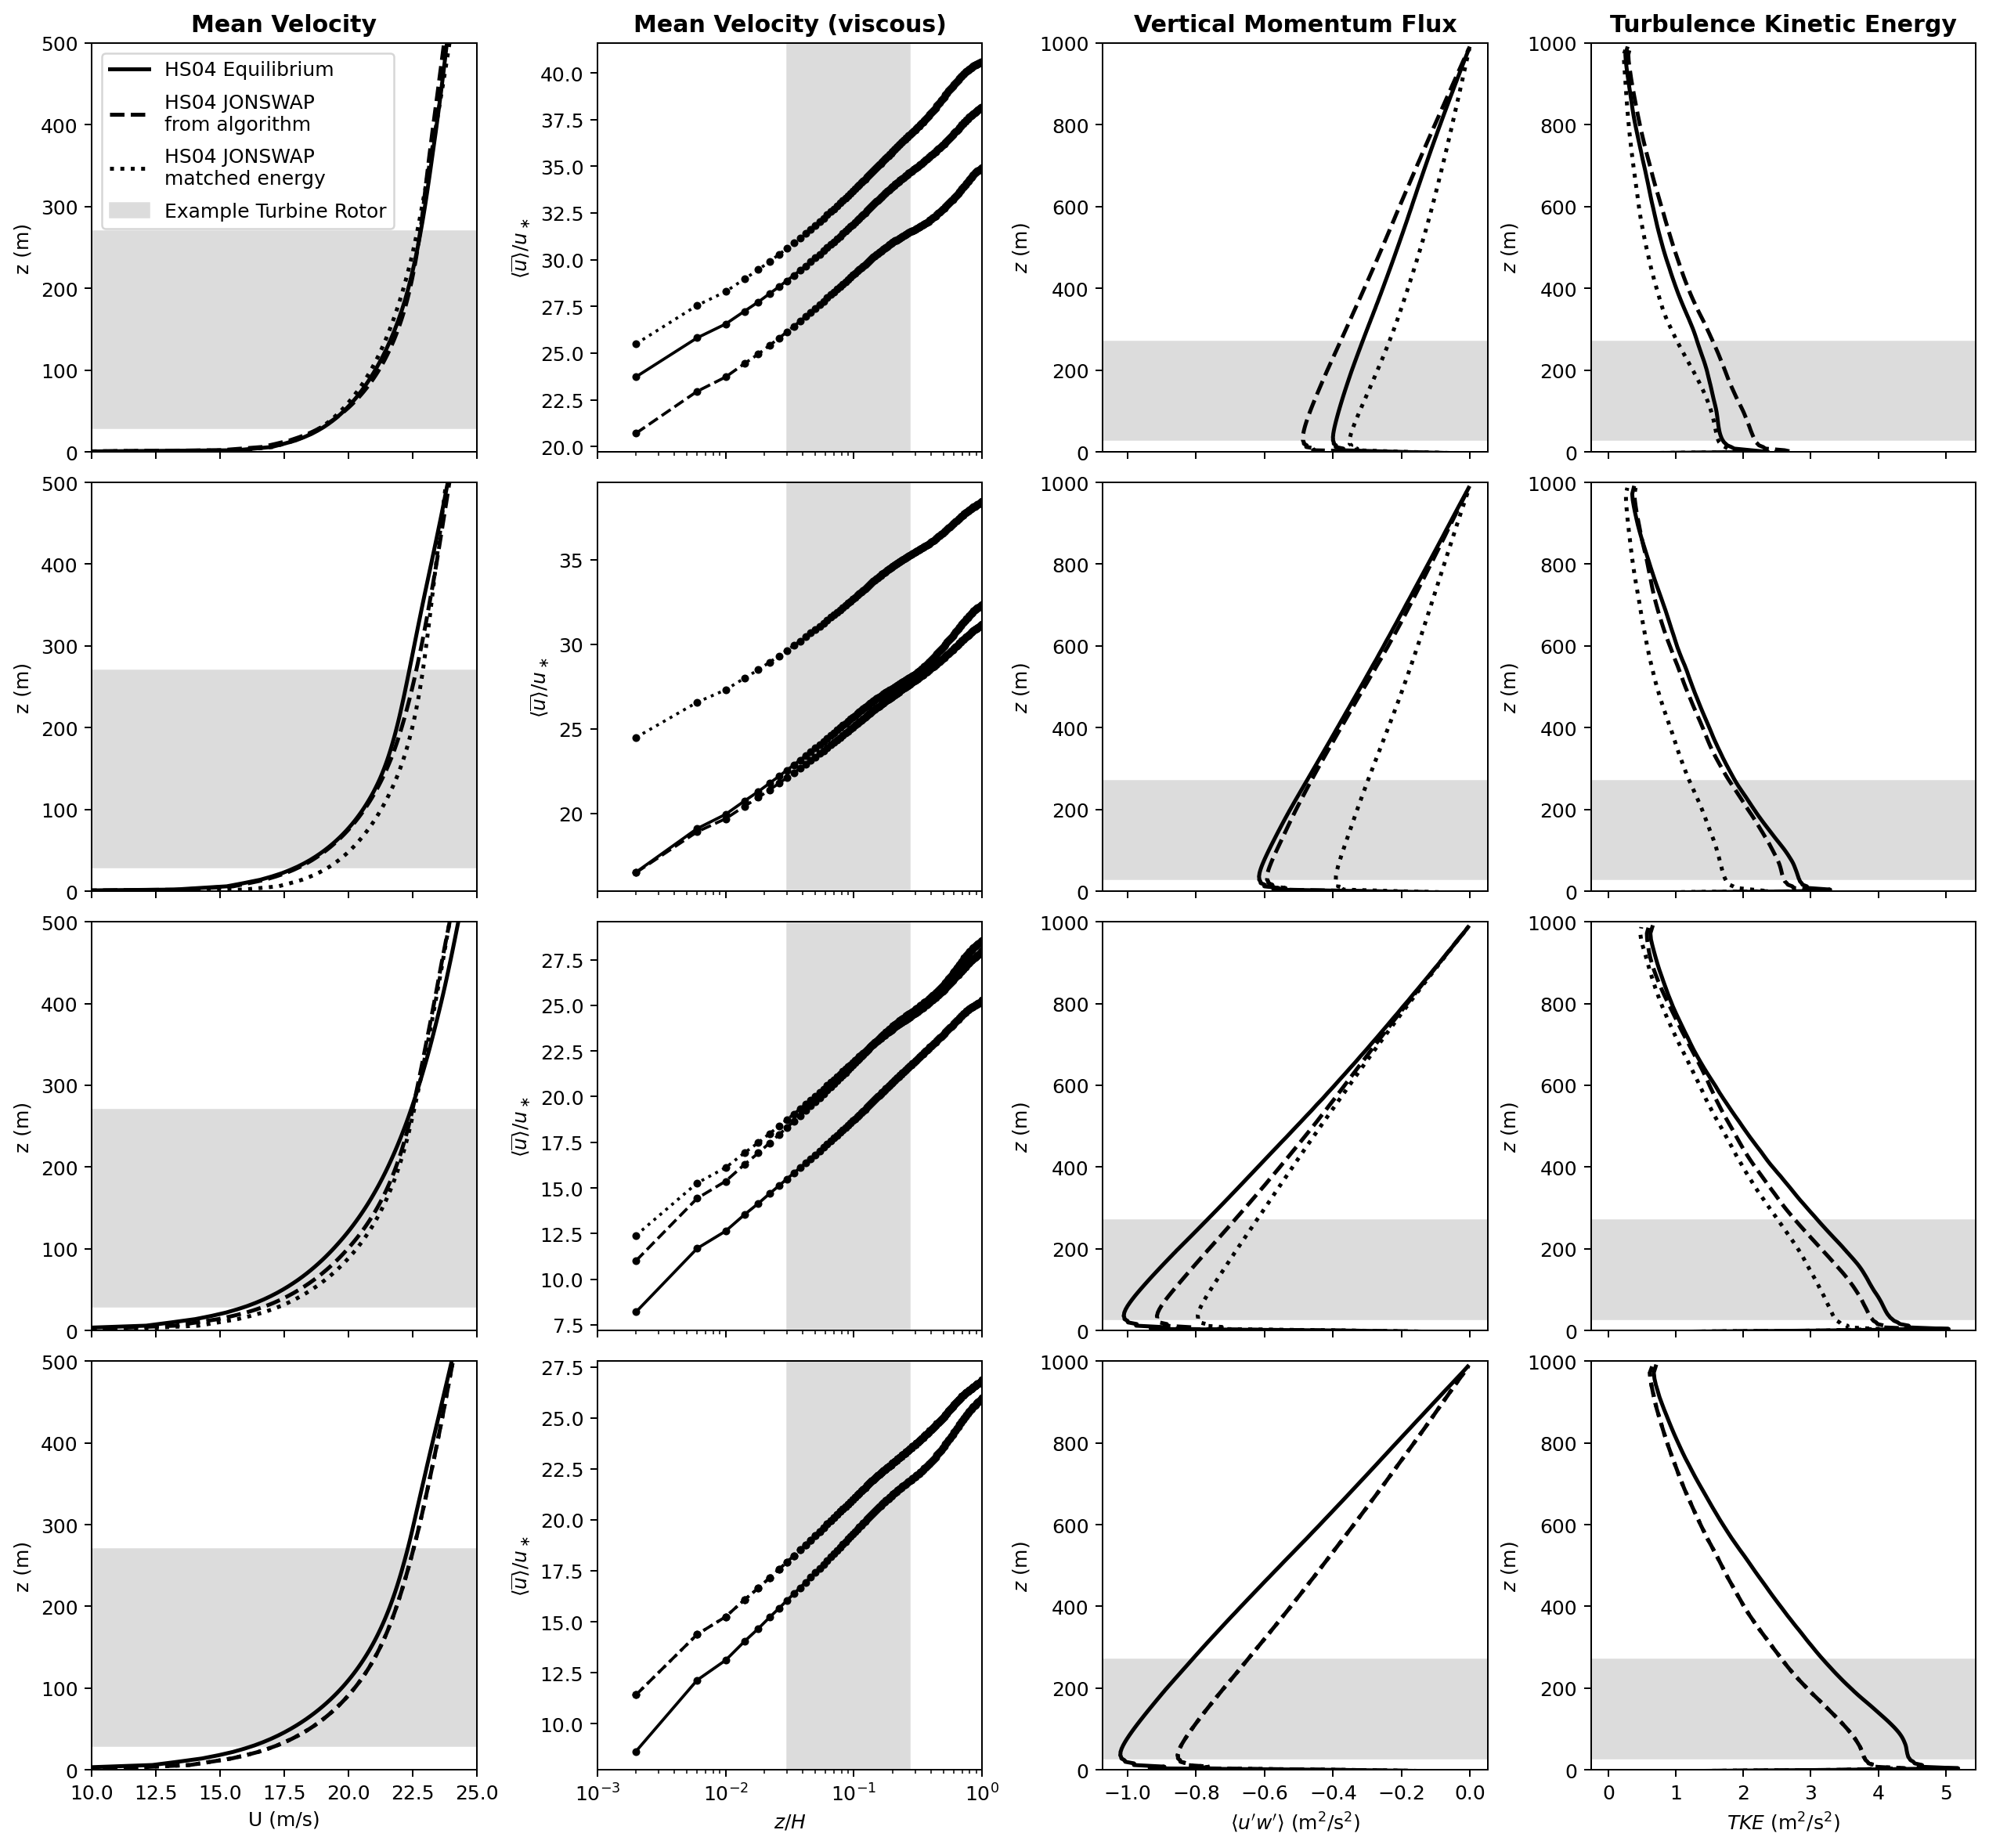

In [32]:
fig, axs = plt.subplots(4,4,facecolor='w', dpi=180.0, figsize=(14,13), sharex='col')

print('Power difference for average velocity at hub height')
print('---------------------------------------------------\n')

plot_wave_profiles(hs04_statlist, hs04_ids, axs[0,:],# '#DEA404',
            color='k', labels=True)
plot_wave_profiles(kp04_statlist, kp04_ids, axs[1,:],# '#4844CB',
            color='k')
plot_wave_profiles(hs20_statlist, hs20_ids, axs[2,:],# '#FAE877',
            color='k')
plot_wave_profiles(kp16_statlist, kp16_ids, axs[3,:],# '#9CBCFF',
            color='k', xlabel=True)

fw = 'semibold'
axs[0,0].set_title('Mean Velocity', weight=fw)
axs[0,1].set_title('Mean Velocity (viscous)', weight=fw)
axs[0,2].set_title('Vertical Momentum Flux', weight=fw)
axs[0,3].set_title('Turbulence Kinetic Energy', weight=fw)

fig.set_constrained_layout(True)
# fig.savefig('figures/all_profiles.pdf')

# print('\n---------------------------------------------------\n')
# print('Spec A power difference 3.50%')
# print('Spec B power difference 5.91%')

### just one case (HS20)



HS20 Equilibrium
U(150): 20.7
U(20): 15.2

HS20 JONSWAP 
from algorithm
U(150): 21.1
U(20): 16.0

HS20 JONSWAP 
matched energy
U(150): 21.3
U(20): 16.7

TKE(150) for HS20 Equilibrium              : 3.76
TKE(150) for HS20 JONSWAP from algorithm   : 3.44
TKE(150) for HS20 JONSWAP matched energy   : 2.99


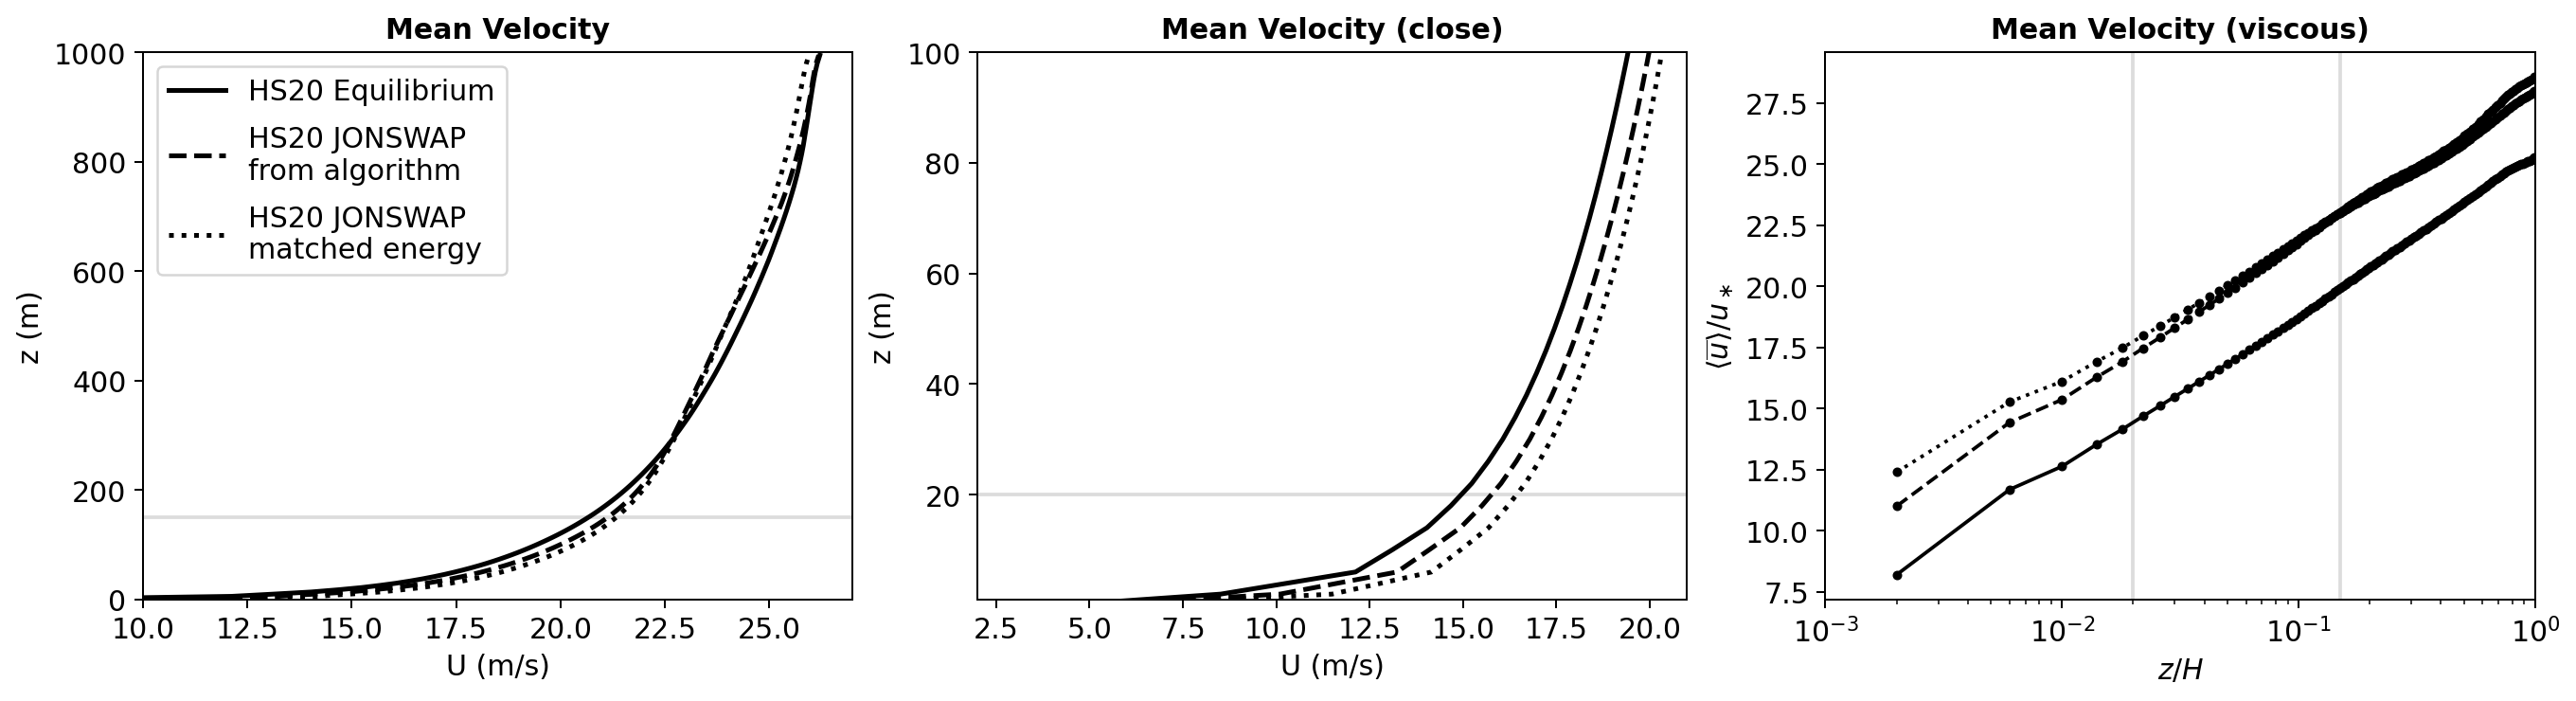

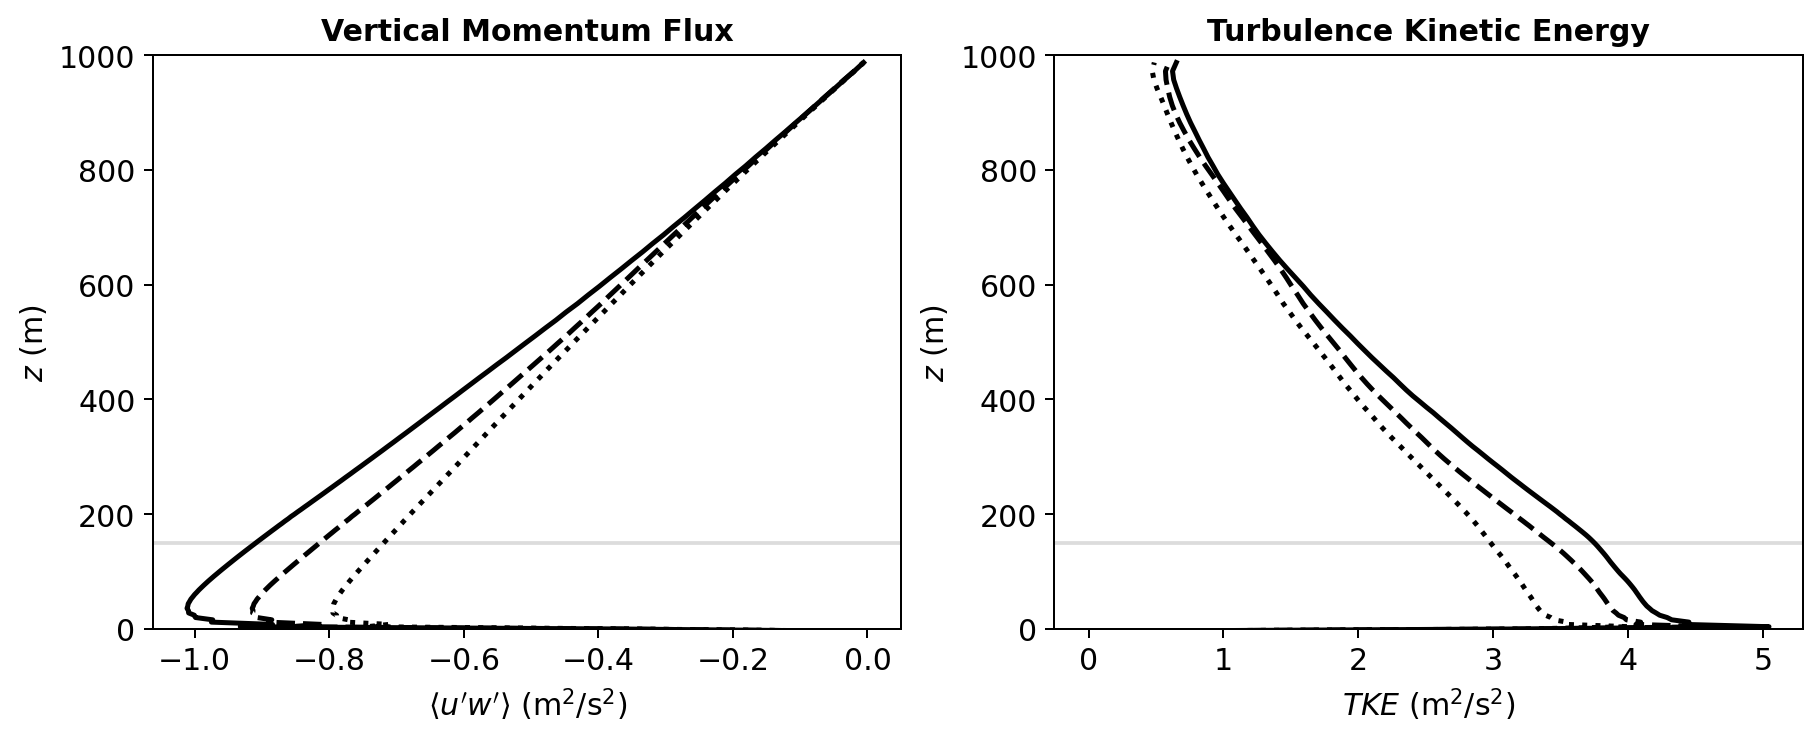

In [38]:
hs20_statlist, hs20_ids = wavecase_statlist(
    U24cases[6:9], 'HS20',
    )

rcParams.update({'font.size': 12})

fig1, axs1 = plt.subplots(1,3,facecolor='w', dpi=180.0, figsize=(15,4))
fig2, axs2 = plt.subplots(1,2,facecolor='w', dpi=180.0, figsize=(10,4))

color = 'k'
ls = ['-','--',':']
colors = [color for i in range(len(ids))]

plot_velocity(hs20_statlist, hs20_ids, colors, 
        axs=axs1, labels=True,
        linestyles=ls, xlabel=True,
        )

plot_upvp(hs20_statlist, hs20_ids, colors, ax=axs2[0], labels=False, xlabel=True,
        linestyles=ls)

plot_tke(hs20_statlist, hs20_ids, colors, ax=axs2[1], labels=False, xlabel=True,
        linestyles=ls)


fw = 'semibold'
fs = 12
axs1[0].set_title('Mean Velocity', weight=fw, fontsize=fs)
axs1[1].set_title('Mean Velocity (close)', weight=fw, fontsize=fs)
axs1[2].set_title('Mean Velocity (viscous)', weight=fw, fontsize=fs)
axs2[0].set_title('Vertical Momentum Flux', weight=fw, fontsize=fs)
axs2[1].set_title('Turbulence Kinetic Energy', weight=fw, fontsize=fs)

fig1.set_constrained_layout(True)
fig2.set_constrained_layout(True)

# fig1.savefig('figures/hs20_profiles_1.pdf')
# fig2.savefig('figures/hs20_profiles_2.pdf')

# plotting equivalent z0 changes

In [14]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

U18cases = ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match']
U_ids = ['Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
       'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       'Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
       'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched']

U_cases = ['HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'HS12_kp16_swell', 'kp16_js', 'kp16_js_match']

U24cases = ['U24_'+cname for cname in U_cases]
U24ids = ['U24 '+idname for idname in U_ids]

U12cases = ['U12_'+cname for cname in U_cases]
U12ids = ['U12 '+idname for idname in U_ids]

U18ids = ['U18 '+idname for idname in U_ids]

cases = U12cases + U18cases + U24cases
ids = U12ids + U18ids + U24ids

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)



z_us = [0, 100]
ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]
z0s = [z0(u10, us) for u10, us in zip(u10s, ustars)]

colors = ['#DEA404', '#4844CB', '#FAE877', '#9CBCFF']
colors = np.tile(colors, 3)


In [15]:
def add_shape_legend(ax):
    shape_labels = ['Equilibrium', 'JONSWAP algorithm', r'JONSWAP matched $\int\phi dk$']
    shape_handles = [
        Line2D([0], [0], marker=m, color='k', markerfacecolor='white',
            linestyle='None', markersize=8)
        for m in markers ]
    leg1 = ax.legend(shape_handles, shape_labels, fontsize=9,
                    loc="upper left",
                    bbox_to_anchor=(1.001, 0.745))

    ax.add_artist(leg1)

In [16]:
def add_color_legend(ax):
    color_labels = [r'low $H_s$',# ($H_sk_p$=0.031)',
                    r'low $k_p$',# ($H_sk_p$=0.047)',
                    r'high $H_s$',# ($H_sk_p$=0.157)',
                    r'high $k_p$',# ($H_sk_p$=0.188)']
    ]
    color_handles = [
        Patch(facecolor=c, edgecolor='none')
        for c in colors ]

    leg2 = ax.legend(color_handles, color_labels, fontsize=9,
                    loc="upper left",
                    bbox_to_anchor=(1.001, 0.5))

    ax.add_artist(leg2)

### $z_0$ vs. $U_{bulk}

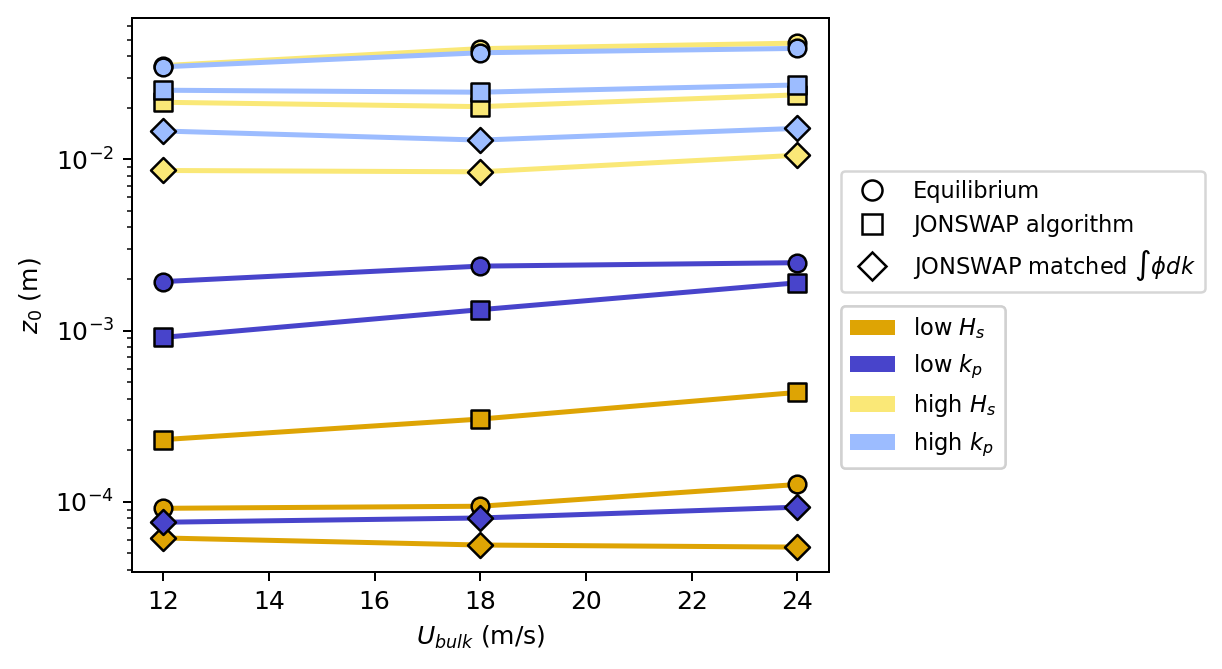

In [18]:

xs = np.repeat([12, 18, 24], 12)
# print(xs)

markers = ['o', 's', 'D']

fig = plt.figure(dpi=180.0, figsize=(5,4))

# eyes = np.arange(int(len(statlist)/3)) * 3 + 1
for i in range(12):
    xdata = [xs[j] for j in [i, i+12, i+24]]
    ydata = [z0s[j] for j in [i, i+12, i+24]]
    plt.plot(xdata, ydata,
             color=colors[int(i/3)], lw=2, zorder=2)

for i in range(len(statlist)):
    plt.scatter(xs[i], z0s[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    
plt.yscale('log')

plt.xlabel(r'$U_{bulk}$ (m/s)')
plt.ylabel(r'$z_0$ (m)')

# * legend
ax = plt.gca()
add_shape_legend(ax)
add_color_legend(ax)

fig.savefig('figures/z0_by_ubulk.pdf')

### $z_0$ by parameterization type

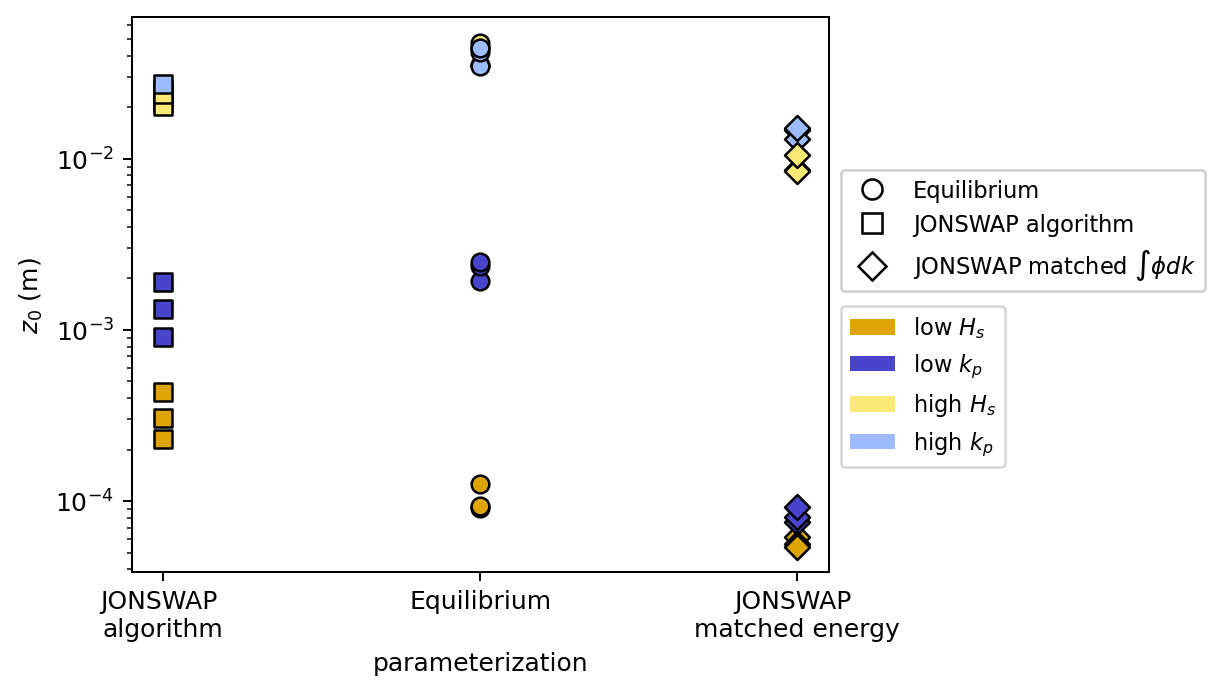

In [19]:

xs = np.tile([1, 0, 2], 12)
markers = ['o', 's', 'D']

fig = plt.figure(dpi=180.0, figsize=(5,4))

eyes = np.arange(int(len(statlist)/3)) * 3 + 1
# print(eyes)
# for i in eyes:
#     xdata = [xs[j] for j in [i, i-1, i+1]]
#     ydata = [z0s[j] for j in [i, i-1, i+1]]
#     plt.plot(xdata, ydata,
#              color=colors[int(i/3)], lw=2, zorder=2)

for i in range(len(statlist)):
    plt.scatter(xs[i], z0s[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    
plt.yscale('log')

plt.xlabel('parameterization')
plt.ylabel(r'$z_0$ (m)')

xlabels = ['JONSWAP \nalgorithm', 'Equilibrium', 'JONSWAP \nmatched energy']
plt.xticks([0,1,2], xlabels)

# * legend
ax = plt.gca()
add_color_legend(ax)
add_shape_legend(ax)

fig.savefig('figures/z0_by_param.pdf')

### normalized difference in reference to equilibrium spectrum 
... by $u_\ast$ value?

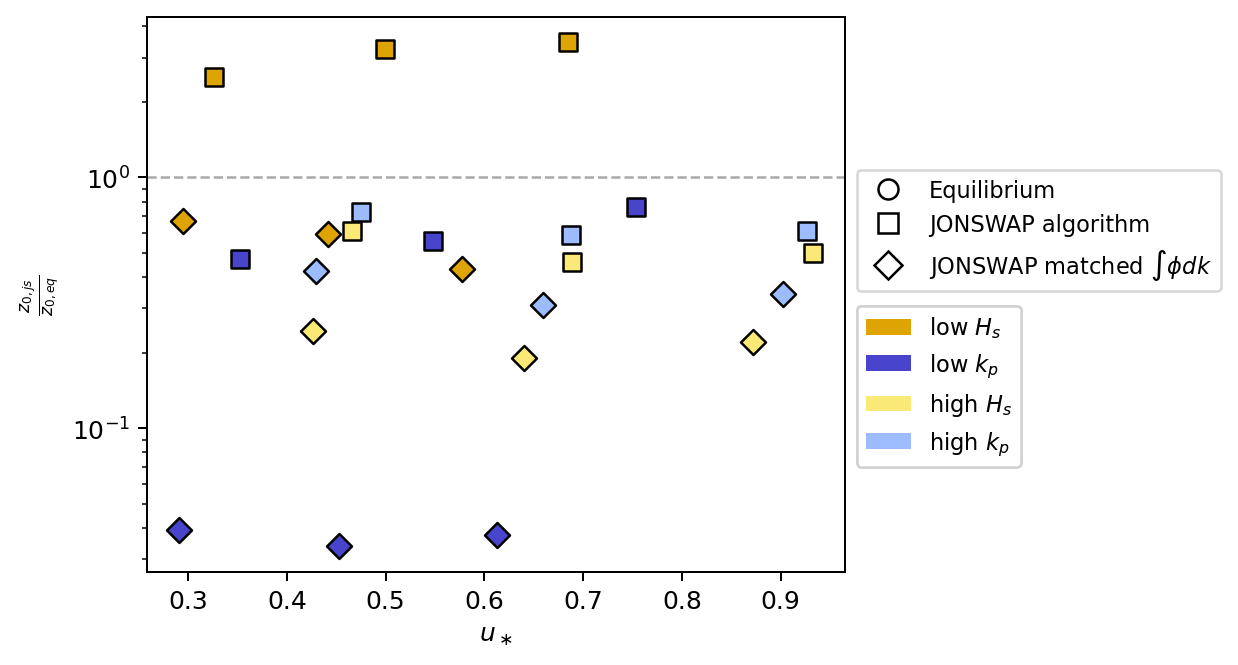

In [ ]:
# i%3 == 1: js alg
# i%3 == 2: js matched

plt.figure(dpi=180.0, figsize=(5,4))
ax = plt.gca()

for i in range(len(ustars)):

    if i%3 == 1:
        R = z0s[i] / z0s[i-1]
        ax.scatter(ustars[i], R, marker='s', color=colors[int(i/3)],
        zorder=3, edgecolor='black', s=50)
    elif i%3 == 2:
        R = z0s[i] / z0s[i-2]
        ax.scatter(ustars[i], R, marker='D', color=colors[int(i/3)],
        zorder=3, edgecolor='black', s=50)

ax.axhline(1, ls='--', lw=1, zorder=1, color='darkgray')

ax.set_yscale('log')
ax.set_xlabel(r'$u_\ast$')
ax.set_ylabel(r'$\frac{z_{0, js}}{z_{0, eq}}$')

add_shape_legend(ax)
add_color_legend(ax)

try also by parameterization

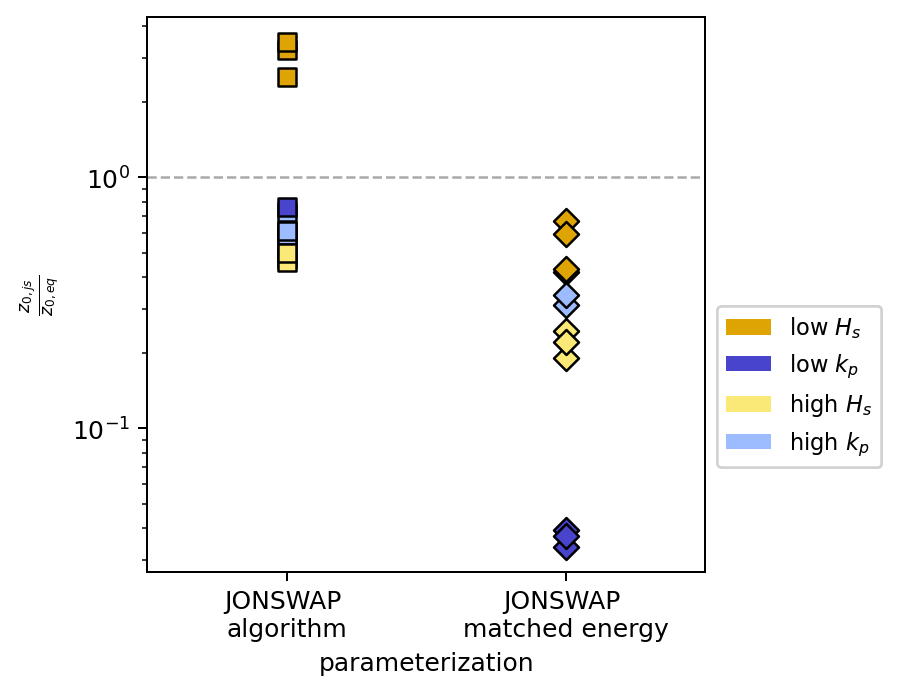

In [52]:

xs = np.tile([-1, 0, 1], 12)
markers = ['o', 's', 'D']

plt.figure(dpi=180.0, figsize=(4,4))
ax = plt.gca()

for i in range(len(statlist)):

    if i%3 == 1:
        R = z0s[i] / z0s[i-1]
        ax.scatter(xs[i], R, marker='s', color=colors[int(i/3)],
        zorder=3, edgecolor='black', s=50)
    elif i%3 == 2:
        R = z0s[i] / z0s[i-2]
        ax.scatter(xs[i], R, marker='D', color=colors[int(i/3)],
        zorder=3, edgecolor='black', s=50)

ax.axhline(1, ls='--', lw=1, zorder=1, color='darkgray')

ax.set_yscale('log')
ax.set_ylabel(r'$\frac{z_{0, js}}{z_{0, eq}}$')

ax.set_xlabel('parameterization')
xlabels = ['JONSWAP \nalgorithm', 'JONSWAP \nmatched energy']
ax.set_xticks([0,1], xlabels)
ax.set_xlim((-0.5,1.5))

# add_shape_legend(ax)
add_color_legend(ax)

### $z_0/z_{0,ch}$ over $u_\ast$

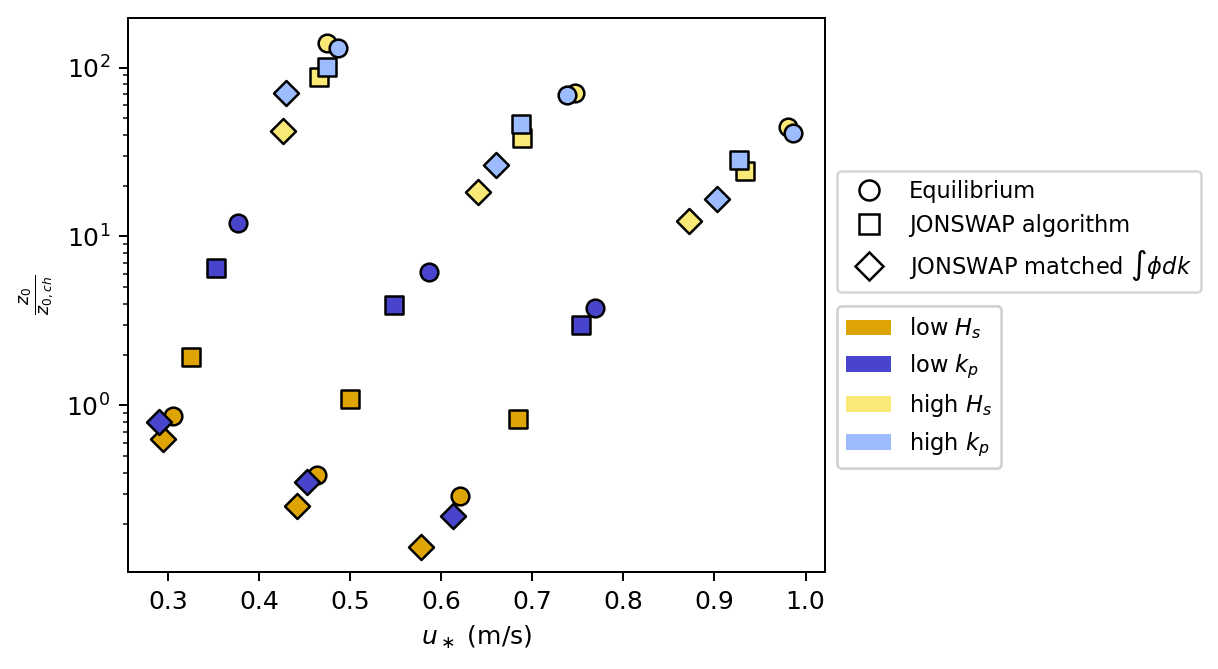

In [15]:

markers = ['o', 's', 'D']

plt.figure(dpi=180.0, figsize=(5,4))

for i in range(len(statlist)):
    z0_ch = ustars[i]**2 / 9.81 * 0.011
    plt.scatter(ustars[i], z0s[i]/z0_ch, c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    
plt.yscale('log')

plt.ylabel(r'$\frac{z_0}{z_{0,ch}}$')
plt.xlabel(r'$u_\ast$ (m/s)')

# * legend
ax = plt.gca()
add_shape_legend(ax)
add_color_legend(ax)

### a sensitivity thing?

In [ ]:
z0s = np.array(z0s)
z0s = z0s.reshape(3, 4, 3)


LOW_HS = 0
LOW_KP = 1
HIGH_HS = 2
HIGH_KP = 3

eq = 0
jsa = 1
jsm = 2

dhs =  np.log10(2/0.4)
dkp = np.log10(0.157/0.0393)

sens_Hs = np.zeros((3, 3))
sens_kp = np.zeros((3, 3))

for ubi in range(3):
    for spi in range(3):
        sens_Hs[ubi, spi] = np.log10(z0s[ubi, HIGH_HS, spi]/z0s[ubi, LOW_HS, spi])/dhs
        sens_kp[ubi, spi] = np.log10(z0s[ubi, HIGH_KP, spi]/z0s[ubi, LOW_KP, spi])/dkp

Hs_vals = sens_Hs.flatten()
kp_vals = sens_kp.flatten()


U_labels = np.repeat([12, 18, 24], 3)  # or your actual values
param_labels = np.tile(['A','B','C'], 3)


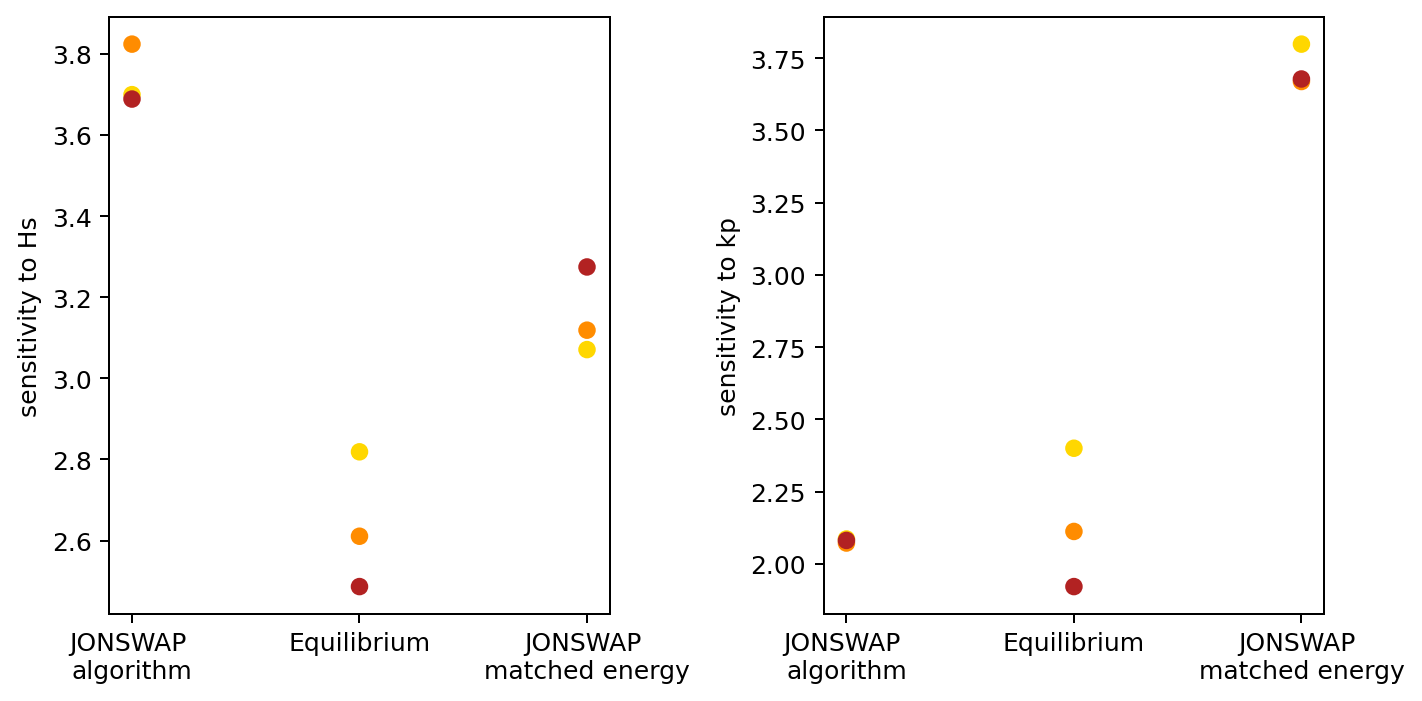

In [72]:

fig, axs = plt.subplots(1, 2, dpi=180.0, figsize=(8,4))
# ax = plt.gca()



colors = ['gold', 'darkorange', 'firebrick']

for spi in range(3):
    axs[0].scatter(spi*np.ones(3), sens_Hs[:, spi], c=colors)
    axs[1].scatter(spi*np.ones(3), sens_kp[:, spi], c=colors)

xlabels = ['JONSWAP \nalgorithm', 'Equilibrium', 'JONSWAP \nmatched energy']
for ax in axs:
    ax.set_xticks([0,1,2], xlabels)

axs[0].set_ylabel('sensitivity to Hs')
axs[1].set_ylabel('sensitivity to kp')

fig.tight_layout()

# axs[0].legend()
# for p in range(3):
#     plt.scatter(sens_Hs[:, p], sens_kp[:, p],
#                 color=colors[p], label=f'Param {"ABC"[p]}')

# plt.legend()
# plt.xlabel('Hs sensitivity')
# plt.ylabel('kp sensitivity')
# plt.show()




# add_shape_legend(ax)
# add_color_legend(ax)

ok this was crazy lol

<!-- # misc other stuff -->